# LSTM (daily input, Friday-only weekly target)

Mixed-frequency neural extension of `06_lstm.ipynb`. Same weekly Friday-to-Friday silver-return
target and the **same 174 W-FRI evaluation dates** as every other model (directly comparable),
but the LSTM is fed **daily** sequences instead of weekly ones.

**Why this notebook.** A weekly LSTM sees ~355 weekly steps, one row per week — a thin use of a
sequence model. Here it ingests the daily path: the natural input for a recurrent net and the
neural analogue of the daily MIDAS (`midas_daily`). It also lets us train on ~5× more (overlapping) rows.

**Setup — overlapping train / Friday-only eval.**
- **Train (overlapping):** every trading day `t` is an origin — input = the last `LOOKBACK` daily
  rows ending at `t`; target = the cumulative silver return over the next `HORIZON=5` trading days.
  ~1,700 examples. Built per split, so no target spills across train/val/test.
- **Eval (Friday-only, non-overlapping):** at each test Friday, input = the last `LOOKBACK` daily
  rows ending on the **prior** Friday; target = the **canonical weekly `silver_return`** of that
  week (from `features_weekly.csv`). Exactly the 174 test Fridays used by ARIMA / XGB / RF /
  weekly-LSTM → apples-to-apples.

**Honest caveat (small-N).** Overlapping windows give the optimiser ~5× more rows, but adjacent
5-day targets share 4 of 5 days, so the *effective independent* sample is still ≈ the weekly count
(~340). This stabilises training; it does **not** add independent information about weekly returns
and is **not** expected to beat drift. It is the mixed-frequency neural extension — we expect a
stronger semi-strong null, not a win.

**Holiday weeks.** The training target is a fixed 5-trading-day-ahead return; in ~33 holiday-shortened
weeks this differs slightly from the calendar week (corr 0.96 vs the canonical weekly) — inherent to
fixed-horizon overlapping targets. The **eval** target is always the canonical weekly return, so the
model comparison is unaffected.

**Features (daily).** From `data/processed/{train,val,test}.csv`: silver + 6 cross-asset returns
(EXOG base), `gs_ratio_z` (GS), squared returns (NonLin), daily-native TECH indicators
(horizon-matched windows, `02_features §2`), monthly macro broadcast to daily point-in-time (MACRO),
FRED-daily changes, COT positioning, Reddit/News sentiment. Full ablation ladder mirrors `06_lstm`.

### Roadmap

| § | Step | What happens |
|---|---|---|
| 1 | Hyperparameters | `LOOKBACK=60` trading-day window, `HORIZON=5`, `HIDDEN` / `DROPOUT` + device (MPS→CUDA→CPU), `SEED=42`. |
| 2 | Load daily splits + target | Read the daily `train/val/test.csv`; build overlapping daily training sequences and the Friday-only eval target (canonical weekly `silver_return` from `features_weekly.csv`). |
| 3 | Architecture & helpers | Single-layer LSTM with an explicit dropout before the head; daily sequence builder + train/eval helpers. |
| 4 | Hyperparameter tuning | Mini-grid tuned **once** on `LSTM-d-EXOG` by val loss + early stopping; the best config is reused across all variants. |
| 5 | Train variants | Train each variant once, predict the 174 Friday targets in one pass — the 17-rung `LSTM-d-*` ladder (incl. `LSTM-d-Y`), mirroring `06_lstm`. |
| 5b | Training diagnostics | Per-variant train-vs-val loss curves. |
| 6 | Results | One table — RMSE / MAE / OOS R² / DA / WDA for Naive, Drift, and every variant. Save `metrics_lstm_daily_weekly.csv`. |
| 7 | Sub-period robustness | Pick the best variant by RMSE (primary) and WDA (secondary); break down by `PERIODS`; save period + preds CSVs. |
| 8 | Predicted vs actual | Full window, two panels (WDA-best, RMSE-best), drift overlaid. |
| 9 | Significance tests | Load-bearing DM vs-Drift floor (OOS R² + DM, squared & absolute error). 9b: Pesaran–Timmermann directional lens. 9c: ex-2025 robustness. |
| 10 | 2026 zoom | WDA-best and RMSE-best vs the drift floor on the 2026 YTD slice. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings, os, sys
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 120

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: mps


## 1. Hyperparameters

Defaults set in the next cell. **`LOOKBACK`, `HIDDEN`, `DROPOUT` are overwritten by the §4 grid
search** (tuned once on EXOG, reused across variants); the rest stay fixed.

| Param | Default | Tuned §4 | Role |
|---|---|:---:|---|
| `LOOKBACK` | 60 | ✓ | Daily lookback — past **trading days** per input sequence (≈3 months). The recurrent context the LSTM learns from. |
| `HORIZON` | 5 | — | Target horizon in **trading days** — cumulative next-5-day silver return (≈ one week). |
| `HIDDEN` | 32 | ✓ | LSTM hidden-state width. |
| `N_LAYERS` | 1 | — | Stacked LSTM layers. |
| `DROPOUT` | 0.2 | ✓ | Dropout applied to the final hidden state before the linear head. `nn.LSTM`'s built-in dropout is a no-op with a single layer, so an explicit `nn.Dropout` is used instead. |
| `EPOCHS` | 150 | — | Max epochs — early stopping usually triggers first. |
| `LR` | 1e-3 | — | Adam learning rate. |
| `PATIENCE` | 15 | — | Early-stopping patience on val loss. |
| `BATCH` | 32 | — | Mini-batch size — larger than the weekly notebook (~5× more sequences). |

In [2]:
LOOKBACK = 60    # daily lookback: 60 trading days (~3 months)
HORIZON  = 5     # 5 trading days ahead (~1 week)
HIDDEN   = 32
N_LAYERS = 1
DROPOUT  = 0.2
EPOCHS   = 150
LR       = 1e-3
PATIENCE = 15
BATCH    = 32    # ~5x more sequences than the weekly notebook

# Seed-robustness (mirrors 06 §1). The LSTM result is a single random draw (weight init +
# batch shuffle + MPS nondeterminism), so a one-off "beats drift" can be a lucky seed. Every
# variant is trained over these seeds and reported as mean ± std (§6); §7 saves the median-RMSE
# seed as the representative forecast; §8 adds a per-seed "how many seeds beat drift" check.
SEEDS = [42, 0, 1, 2, 3]

TARGET = 'silver_return'

## 2. Load daily splits + canonical weekly target

Five cells, one per feature group — mirrors `06_lstm §2`. All columns come directly from the daily
splits; no weekly join is needed. The last cell loads `features_weekly.csv` only for the canonical
eval target (`silver_return`, test Fridays) and the Drift floor.

In [3]:
# Daily feature splits — source of the LSTM sequences.
train = pd.read_csv('../../../../data/processed/train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv('../../../../data/processed/val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv('../../../../data/processed/test.csv',  index_col=0, parse_dates=True)

EXOG_RETURNS = ['gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return']
MARKET    = [TARGET] + EXOG_RETURNS   # EXOG base = silver + 6 cross-asset daily returns
GS_COLS   = ['gs_ratio_z']
FRED_COLS = ['real_rates_chg', 'breakeven_chg', 'jobless_chg']
COT_COLS  = ['cot_mm_net_pct', 'cot_comm_net_pct']
SENT_COLS = ['reddit_sentiment', 'news_sentiment']
NEWSPAID_COLS = ['news_paid_sentiment_title']                      # paid-news, title only
SENTPAID_COLS = ['reddit_sentiment', 'news_paid_sentiment_title']  # paid twin of SENT_COLS
PMI_COLS      = ['china_pmi_proxy']                                # point-in-time level (lagged by the window)

print(f'Daily rows  train={len(train)}  val={len(val)}  test={len(test)}')
print(f'Base: MARKET({len(MARKET)})  GS({len(GS_COLS)})  FRED({len(FRED_COLS)})  COT({len(COT_COLS)})  SENT({len(SENT_COLS)})')

Daily rows  train=1755  val=251  test=835
Base: MARKET(7)  GS(1)  FRED(3)  COT(2)  SENT(2)


In [4]:
# Daily-native TECH — horizon-matched windows (built in 02_features §2); window supplies the lag.
TECH_COLS = ['macd_line_d', 'macd_hist_d', 'rsi_70d', 'mom_25d', 'roc_65d',
             'roc_130d', 'roc_260d', 'price_ma65d', 'donchian_260d', 'bb_pct_b_d']
print(f'Technical indicators (daily-native, {len(TECH_COLS)}): {TECH_COLS}')

Technical indicators (daily-native, 10): ['macd_line_d', 'macd_hist_d', 'rsi_70d', 'mom_25d', 'roc_65d', 'roc_130d', 'roc_260d', 'price_ma65d', 'donchian_260d', 'bb_pct_b_d']


In [5]:
# Nonlinear: squared daily returns (magnitude / vol regardless of sign).
SQ_COLS = []
for c in MARKET:
    sq = f'{c}_sq'
    for d in (train, val, test):
        d[sq] = d[c] ** 2
    SQ_COLS.append(sq)
print(f'Nonlinear (squared) features added ({len(SQ_COLS)}): {SQ_COLS}')

Nonlinear (squared) features added (7): ['silver_return_sq', 'gold_return_sq', 'usd_return_sq', 'copper_return_sq', 'sp500_return_sq', 'vix_return_sq', 'oil_return_sq']


In [6]:
# Monthly macro broadcast to daily point-in-time step function (built in 02_features §2).
MACRO_COLS = [f'{v}_mlag{k}' for v in ['cpi', 'fed_funds', 'ind_prod', 'm2'] for k in (1, 2, 3)]
print(f'Monthly macro ({len(MACRO_COLS)}): {MACRO_COLS}')

Monthly macro (12): ['cpi_mlag1', 'cpi_mlag2', 'cpi_mlag3', 'fed_funds_mlag1', 'fed_funds_mlag2', 'fed_funds_mlag3', 'ind_prod_mlag1', 'ind_prod_mlag2', 'ind_prod_mlag3', 'm2_mlag1', 'm2_mlag2', 'm2_mlag3']


In [7]:
# Canonical weekly target + test Fridays — Friday-only eval target and Drift floor.
weekly = pd.read_csv('../../../../data/processed/features_weekly.csv', index_col=0, parse_dates=True)
wret   = weekly[TARGET].dropna().sort_index()                 # == W-FRI sum of daily returns
test_fridays = weekly[weekly['split'] == 'test'].index
test_fridays = test_fridays[test_fridays.isin(wret.index)]
print(f'Weekly test Fridays (eval targets): {len(test_fridays)}  '
      f'{test_fridays.min().date()}..{test_fridays.max().date()}')

Weekly test Fridays (eval targets): 174  2023-01-06..2026-05-01


## 3. Architecture & helpers

Four components used by every variant:

- **`LSTMForecaster`** — single-layer LSTM followed by dropout and a linear head. Single layer
  is deliberate: the effective independent sample is still ~330 sequences. Dropout is applied
  to the final hidden state (not between layers, since there is only one).

- **`make_sequences`** — sliding-window builder for the **overlapping training pairs**.
  Every daily origin → cumulative next-`HORIZON` return. Converts a scaled numpy array into
  `(LOOKBACK × n_features)` input tensors and scalar targets.

- **`friday_eval_sequences`** — builds the **non-overlapping test pairs**: window ending
  the prior weekly Friday → canonical weekly return. Warmed from the val tail so all 174
  test Fridays are predicted with no look-ahead.

- **`run_variant`** — trains one variant end-to-end: scales features, builds sequences,
  runs the training loop with early stopping, checkpoints the best model, then predicts
  the 174 test Fridays and un-scales back to raw returns.


In [8]:
import tempfile

class LSTMForecaster(nn.Module):
    """Single-layer LSTM -> Dropout -> Linear(1) regression head.

    Architecture kept minimal: one recurrent layer (stacking would overfit on the
    ~330 effective independent sequences), dropout on the final hidden state, scalar output.
    nn.LSTM's built-in dropout is passed 0.0 because it only acts between stacked
    layers -- the tuned dropout is applied via an explicit nn.Dropout instead.
    """
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(out[:, -1, :]))   # last hidden state -> scalar


def make_sequences(data, seq_len, target_col, horizon):
    """Sliding-window sequence builder for overlapping training pairs.

    Args:
        data:       scaled numpy array (n_timesteps x n_features)
        seq_len:    lookback length -- rows per input window
        target_col: column index of the return target in `data`
        horizon:    number of steps ahead to sum as the target (HORIZON=5 for weekly)
    Returns:
        X: (n_samples, seq_len, n_features)
        y: (n_samples,) -- scaled target values
    """
    X, y = [], []
    for i in range(seq_len, len(data) - horizon + 1):
        X.append(data[i - seq_len:i])
        y.append(np.sum(data[i:i + horizon, target_col]))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def friday_eval_sequences(scaler, cols, target_idx, seq_len):
    """Build non-overlapping Friday-only test pairs.

    For each test Friday, the input window is the last `seq_len` daily rows ending
    on the PRIOR Friday; the target is the canonical weekly silver_return.
    Warmed from the val tail so all 174 test Fridays are predicted -- val precedes
    test (strictly past), so no look-ahead.
    y is the raw (unscaled) weekly return.
    """
    vt   = pd.concat([val, test])
    vt_s = scaler.transform(vt[cols].fillna(0))
    vt_i = vt.index
    X, y, dates = [], [], []
    for f in test_fridays:
        pos = wret.index.get_loc(f)
        if pos == 0:
            continue
        p = vt_i.searchsorted(wret.index[pos - 1], side='right') - 1   # last daily row <= prior Friday
        X.append(vt_s[p - seq_len + 1:p + 1])
        y.append(wret.loc[f])
        dates.append(f)
    return (np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), pd.DatetimeIndex(dates))


LOSS_HISTORIES = {}   # variant -> {train, val, best_epoch}; populated for the §5b loss curves


def run_variant(name, feature_cols, seed):
    """Train one variant (for a single seed) end-to-end and return metrics + predictions.

    Args:
        name:         variant label, e.g. 'LSTM-d-EXOG'.
        feature_cols: the variant's feature columns to feed the model.
        seed:         RNG seed for torch + numpy, set at entry so the run is
                      reproducible up to MPS nondeterminism. §5 calls this once per
                      seed and §6 reports mean ± std, so no single draw is the headline.

    Steps:
      1. Scale features (StandardScaler fit on train only -- no leak).
      2. Build overlapping sequences for train/val; Friday-only sequences for test.
      3. Train with Adam + ReduceLROnPlateau + early stopping; checkpoint the best
         val loss to a temp file (removed at the end -- no per-variant .pt is kept).
      4. Reload best checkpoint, predict the 174 test Fridays, un-scale to raw returns.

    Returns:
        metrics dict, preds array, actuals array, dates index
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    cols       = [c for c in feature_cols if c in train.columns]
    target_idx = cols.index(TARGET)

    # Gradient descent is sensitive to feature scale: large-magnitude inputs produce
    # large gradients that swamp small ones. StandardScaler (mean=0, std=1) levels
    # the playing field. Fit on train only so val/test statistics don't leak in.
    scaler       = StandardScaler().fit(train[cols].fillna(0))
    train_scaled = scaler.transform(train[cols].fillna(0))
    val_scaled   = scaler.transform(val[cols].fillna(0))

    # X: (n_days - LOOKBACK, LOOKBACK, n_features) -- stack of overlapping daily windows
    # y: (n_days - LOOKBACK,) -- one target scalar per window
    # Val is warmed from the train tail so the first val window has a full lookback.
    X_train, y_train = make_sequences(train_scaled, LOOKBACK, target_idx, HORIZON)
    X_val,   y_val   = make_sequences(
        np.concatenate([train_scaled[-(LOOKBACK - 1):], val_scaled]),
        LOOKBACK, target_idx, HORIZON
    )
    # Friday-only test sequences: non-overlapping, warmed from val tail.
    X_test, y_test, dates = friday_eval_sequences(scaler, cols, target_idx, LOOKBACK)

    # DataLoader handles batching and shuffling. Training shuffles to break temporal
    # order within a batch (each sequence is self-contained, so this is fine and
    # helps generalisation). Val stays ordered.
    def to_loader(X, y, shuffle=True):
        ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
        return DataLoader(ds, batch_size=BATCH, shuffle=shuffle)

    train_loader = to_loader(X_train, y_train)
    val_loader   = to_loader(X_val,   y_val,   shuffle=False)

    checkpoint_path = tempfile.NamedTemporaryFile(suffix='.pt', delete=False).name
    model     = LSTMForecaster(len(cols), HIDDEN, N_LAYERS, DROPOUT).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()
    # Halve the learning rate if val loss hasn't improved for 3 epochs.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    best_val_loss, patience_count, best_epoch = np.inf, 0, 0
    hist_train, hist_val = [], []
    for epoch in range(1, EPOCHS + 1):
        # Training mode: enables dropout (randomly zeros hidden units to prevent
        # co-adaptation, i.e. the model learns redundant representations).
        model.train()
        epoch_train_losses = []
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()                        # clear gradients from the previous batch --
                                                         # PyTorch accumulates by default, so must reset
            loss = criterion(model(x_batch), y_batch)   # forward pass: predict, then compute MSE loss
            loss.backward()                              # backprop: compute dLoss/dWeight for every
                                                         # parameter via the chain rule through all layers
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # cap gradient norm --
                                                         # RNNs are prone to exploding gradients through
                                                         # long sequences (many chain-rule multiplications)
            optimizer.step()                             # gradient descent step: w = w - lr * grad
            epoch_train_losses.append(loss.item())

        # Eval mode: disables dropout so predictions are deterministic.
        # no_grad: skips building the computation graph (not needed for inference),
        # saving memory and speeding up the validation pass.
        model.eval()
        with torch.no_grad():
            val_loss = np.mean([criterion(model(x_batch.to(DEVICE)), y_batch.to(DEVICE)).item()
                                for x_batch, y_batch in val_loader])
        scheduler.step(val_loss)
        hist_train.append(float(np.mean(epoch_train_losses)))
        hist_val.append(float(val_loss))

        # Checkpoint the weights whenever val loss improves; revert to this at the
        # end so we return the best generalising model, not the last epoch.
        if val_loss < best_val_loss:
            best_val_loss, patience_count, best_epoch = val_loss, 0, epoch
            torch.save(model.state_dict(), checkpoint_path)
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                break
    LOSS_HISTORIES[name] = {'train': hist_train, 'val': hist_val, 'best_epoch': best_epoch}

    # Reload best checkpoint and predict the 174 test Fridays in one pass; temp ckpt then discarded.
    model.load_state_dict(torch.load(checkpoint_path))
    os.remove(checkpoint_path)
    model.eval()
    with torch.no_grad():
        preds_scaled = model(torch.tensor(X_test).to(DEVICE)).cpu().numpy().flatten()

    # Un-scale: model predicted in standardised units; convert back to raw weekly returns.
    target_mean = scaler.mean_[target_idx]
    target_std  = scaler.scale_[target_idx]
    preds   = preds_scaled * target_std + HORIZON * target_mean
    actuals = y_test   # canonical weekly return (already raw)

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    da   = np.mean(np.sign(actuals) == np.sign(preds))
    wda  = np.sum(np.abs(actuals) * (np.sign(actuals) == np.sign(preds))) / np.sum(np.abs(actuals))
    return {'model': name, 'rmse': rmse, 'mae': mae, 'dir_acc': da, 'wda': wda}, preds, actuals, dates

## 4. Hyperparameter tuning

Mini-grid over `LOOKBACK`, `HIDDEN`, `DROPOUT` evaluated on the **`EXOG`** variant
(silver + 6 cross-asset daily returns) using overlapping-val loss with early stopping.
Best config reused across all variants. `LOOKBACK` is the one genuinely daily-specific
knob: how many trading days of context the LSTM sees.

Tuning on EXOG rather than the kitchen sink is deliberate: with a high-dimensional input
(30+ features) the HP search risks selecting overly conservative regularisation on this
small sample. EXOG gives a cleaner signal about what `LOOKBACK` and `HIDDEN` suit the
data's temporal structure.


In [9]:
from itertools import product

LOOKBACK_GRID = [20, 40, 60]      # daily lookback (~1 / 2 / 3 months)
HIDDEN_GRID   = [16, 32]
DROPOUT_GRID  = [0.1, 0.2, 0.3]

# Tune on EXOG (silver + 6 cross-asset daily returns): gives a cleaner, lower-variance
# HP signal than the kitchen sink. With 30+ features the search risks selecting
# overly conservative regularisation on this small sample.
tune_cols = MARKET


def eval_config(lookback, hidden, dropout):
    """Train one LSTM config on overlapping train pairs; return best val loss."""
    scaler     = StandardScaler().fit(train[tune_cols].fillna(0))
    train_s    = scaler.transform(train[tune_cols].fillna(0))
    val_s      = scaler.transform(val[tune_cols].fillna(0))
    target_idx = tune_cols.index(TARGET)

    X_train, y_train = make_sequences(train_s, lookback, target_idx, HORIZON)
    X_val,   y_val   = make_sequences(
        np.concatenate([train_s[-(lookback - 1):], val_s]),
        lookback, target_idx, HORIZON
    )
    if len(X_train) == 0 or len(X_val) == 0:
        return np.inf

    train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train).unsqueeze(1)),
                              batch_size=BATCH, shuffle=True)
    val_loader   = DataLoader(TensorDataset(torch.tensor(X_val),   torch.tensor(y_val).unsqueeze(1)),
                              batch_size=BATCH, shuffle=False)

    model     = LSTMForecaster(len(tune_cols), hidden, N_LAYERS, dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    best_val_loss, patience_count = np.inf, 0
    for _ in range(EPOCHS):
        model.train()
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss = np.mean([criterion(model(x_batch.to(DEVICE)), y_batch.to(DEVICE)).item()
                                for x_batch, y_batch in val_loader])
        if val_loss < best_val_loss:
            best_val_loss, patience_count = val_loss, 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                break
    return best_val_loss


configs = list(product(LOOKBACK_GRID, HIDDEN_GRID, DROPOUT_GRID))
print(f'Tuning on EXOG variant ({len(tune_cols)} features) - {len(configs)} configs')
print('-' * 60)

search = []
for lookback, hidden, dropout in configs:
    val_loss = eval_config(lookback, hidden, dropout)
    print(f'  LOOKBACK={lookback:>3}  HIDDEN={hidden:>3}  DROPOUT={dropout}  val_loss={val_loss:.6f}')
    search.append({'lookback': lookback, 'hidden': hidden, 'dropout': dropout, 'val_loss': val_loss})

best = min(search, key=lambda r: r['val_loss'])
print(f'\nBest:  LOOKBACK={best["lookback"]}  HIDDEN={best["hidden"]}' 
      f'  DROPOUT={best["dropout"]}  val_loss={best["val_loss"]:.6f}')

LOOKBACK, HIDDEN, DROPOUT = best['lookback'], best['hidden'], best['dropout']


Tuning on EXOG variant (7 features) - 18 configs
------------------------------------------------------------
  LOOKBACK= 20  HIDDEN= 16  DROPOUT=0.1  val_loss=6.716359
  LOOKBACK= 20  HIDDEN= 16  DROPOUT=0.2  val_loss=6.706147
  LOOKBACK= 20  HIDDEN= 16  DROPOUT=0.3  val_loss=6.761705
  LOOKBACK= 20  HIDDEN= 32  DROPOUT=0.1  val_loss=6.718618
  LOOKBACK= 20  HIDDEN= 32  DROPOUT=0.2  val_loss=6.728412
  LOOKBACK= 20  HIDDEN= 32  DROPOUT=0.3  val_loss=6.748730
  LOOKBACK= 40  HIDDEN= 16  DROPOUT=0.1  val_loss=6.735748
  LOOKBACK= 40  HIDDEN= 16  DROPOUT=0.2  val_loss=6.730423
  LOOKBACK= 40  HIDDEN= 16  DROPOUT=0.3  val_loss=6.739836
  LOOKBACK= 40  HIDDEN= 32  DROPOUT=0.1  val_loss=6.732479
  LOOKBACK= 40  HIDDEN= 32  DROPOUT=0.2  val_loss=6.731191
  LOOKBACK= 40  HIDDEN= 32  DROPOUT=0.3  val_loss=6.739577
  LOOKBACK= 60  HIDDEN= 16  DROPOUT=0.1  val_loss=6.767036
  LOOKBACK= 60  HIDDEN= 16  DROPOUT=0.2  val_loss=6.781977
  LOOKBACK= 60  HIDDEN= 16  DROPOUT=0.3  val_loss=6.717583
  LOO

## 5. Train variants

Each variant is trained over **`SEEDS`** (5 seeds) rather than once — the LSTM result is a
single random draw (weight init + batch shuffle + MPS nondeterminism), so a one-off "beats
drift" can be a lucky seed. §6 reports every variant as **mean ± std** over the seeds; §7 saves
the **median-RMSE seed** as the representative forecast for the cross-model comparison; §8 adds a
per-seed "how many seeds beat drift" robustness check.

In [10]:
MARKET_FEATURES = MARKET   # EXOG base (silver + 6 cross-asset daily returns)

variants = {
    'LSTM-d-Y':                     [TARGET],
    'LSTM-d-TECH':                  [TARGET] + TECH_COLS,
    'LSTM-d-EXOG':                  MARKET_FEATURES,
    'LSTM-d-EXOG-GS':               MARKET_FEATURES + GS_COLS,
    'LSTM-d-EXOG-NONLIN':           MARKET_FEATURES + SQ_COLS,
    'LSTM-d-EXOG-TECH':             MARKET_FEATURES + TECH_COLS,
    'LSTM-d-EXOG-MACRO':            MARKET_FEATURES + MACRO_COLS,
    'LSTM-d-EXOG-FRED':             MARKET_FEATURES + FRED_COLS,
    'LSTM-d-EXOG-COT':              MARKET_FEATURES + COT_COLS,
    'LSTM-d-EXOG-FRED-COT':         MARKET_FEATURES + FRED_COLS + COT_COLS,
    'LSTM-d-EXOG-REDDIT':           MARKET_FEATURES + ['reddit_sentiment'],
    'LSTM-d-EXOG-NEWS':             MARKET_FEATURES + ['news_sentiment'],
    'LSTM-d-EXOG-SENTIMENT':        MARKET_FEATURES + SENT_COLS,
    'LSTM-d-EXOG-GS-SENTIMENT':     MARKET_FEATURES + GS_COLS + SENT_COLS,
    'LSTM-d-EXOG-NONLIN-SENTIMENT': MARKET_FEATURES + SQ_COLS + SENT_COLS,
    'LSTM-d-EXOG-TECH-SENTIMENT':   MARKET_FEATURES + TECH_COLS + SENT_COLS,
    # Kitchen sink: GS + NonLin + Tech + FRED + COT + Sentiment (MACRO left out, mirroring 06's ALL).
    'LSTM-d-EXOG-ALL':              MARKET_FEATURES + GS_COLS + SQ_COLS + TECH_COLS + FRED_COLS + COT_COLS + SENT_COLS,
    # Paid-news (title-only) twins -- mirror every GDELT-news rung
    'LSTM-d-EXOG-NEWSPAID':             MARKET_FEATURES + NEWSPAID_COLS,
    'LSTM-d-EXOG-SENTIMENTPAID':        MARKET_FEATURES + SENTPAID_COLS,
    'LSTM-d-EXOG-GS-SENTIMENTPAID':     MARKET_FEATURES + GS_COLS + SENTPAID_COLS,
    'LSTM-d-EXOG-NONLIN-SENTIMENTPAID': MARKET_FEATURES + SQ_COLS + SENTPAID_COLS,
    'LSTM-d-EXOG-TECH-SENTIMENTPAID':   MARKET_FEATURES + TECH_COLS + SENTPAID_COLS,
    'LSTM-d-EXOG-ALLPAID':             MARKET_FEATURES + GS_COLS + SQ_COLS + TECH_COLS + FRED_COLS + COT_COLS + SENTPAID_COLS,
    # PMI on the FRED rungs (china_pmi_proxy point-in-time level)
    'LSTM-d-EXOG-FRED-PMI':            MARKET_FEATURES + FRED_COLS + PMI_COLS,
    'LSTM-d-EXOG-FRED-COT-PMI':        MARKET_FEATURES + FRED_COLS + COT_COLS + PMI_COLS,
    'LSTM-d-EXOG-ALL-PMI':            MARKET_FEATURES + GS_COLS + SQ_COLS + TECH_COLS + FRED_COLS + COT_COLS + SENT_COLS + PMI_COLS,
}

# Train every variant over SEEDS; keep the per-seed test predictions. §6 turns these into
# mean ± std metrics and picks each variant's median-RMSE seed as its representative forecast.
SEED_PREDS  = {}     # name -> (n_seeds, n_test) per-seed test predictions
actuals_arr = None
dates_arr   = None

print(f'Training {len(variants)} variants x {len(SEEDS)} seeds = {len(variants) * len(SEEDS)} runs '
      f'(seeds={SEEDS})...')
for name, cols in variants.items():
    seed_arrs = []
    for sd in SEEDS:
        _m, preds, acts, dates = run_variant(name, cols, sd)
        seed_arrs.append(preds)
        actuals_arr, dates_arr = acts, dates
    SEED_PREDS[name] = np.array(seed_arrs)
    _r = np.sqrt(((SEED_PREDS[name] - actuals_arr) ** 2).mean(axis=1)) * 100   # per-seed RMSE %
    print(f'  {name:<30}  RMSE {_r.mean():5.2f} ± {_r.std():.2f}%')

Training 17 variants x 5 seeds = 85 runs (seeds=[42, 0, 1, 2, 3])...
  LSTM-d-Y                        RMSE  5.17 ± 0.02%
  LSTM-d-TECH                     RMSE  5.23 ± 0.02%
  LSTM-d-EXOG                     RMSE  5.19 ± 0.01%
  LSTM-d-EXOG-GS                  RMSE  5.17 ± 0.01%
  LSTM-d-EXOG-NONLIN              RMSE  5.19 ± 0.01%
  LSTM-d-EXOG-TECH                RMSE  5.27 ± 0.07%
  LSTM-d-EXOG-MACRO               RMSE  5.18 ± 0.02%
  LSTM-d-EXOG-FRED                RMSE  5.26 ± 0.07%
  LSTM-d-EXOG-COT                 RMSE  5.17 ± 0.01%
  LSTM-d-EXOG-FRED-COT            RMSE  5.19 ± 0.02%
  LSTM-d-EXOG-REDDIT              RMSE  5.20 ± 0.01%
  LSTM-d-EXOG-NEWS                RMSE  5.20 ± 0.01%
  LSTM-d-EXOG-SENTIMENT           RMSE  5.18 ± 0.01%
  LSTM-d-EXOG-GS-SENTIMENT        RMSE  5.17 ± 0.01%
  LSTM-d-EXOG-NONLIN-SENTIMENT    RMSE  5.21 ± 0.01%
  LSTM-d-EXOG-TECH-SENTIMENT      RMSE  5.21 ± 0.04%
  LSTM-d-EXOG-ALL                 RMSE  5.17 ± 0.02%


## 5b. Training diagnostics — loss curves

Per-epoch **train vs validation MSE** (standardised ~weekly returns), captured during §5 at no cost.
Variants are **ranked by their best (minimum) validation loss**; the lowest is highlighted in the
right panel and shown train-vs-val on the left (dashed line = early-stopping `best_epoch`).

> Note the whole band sits **above ~1.0** (= predicting the train mean), so even the "best"
> variant has *negative* out-of-sample R² — "converges lower" means *less bad*, not skill. It
> still has to beat the Drift on the **test** set (§6/§9), which it doesn't.

rank  variant                          min val  @epoch  final val
------------------------------------------------------------------
   1  LSTM-d-EXOG-MACRO                 6.3678       9     7.0663
   2  LSTM-d-Y                          6.4127      15     6.4622
   3  LSTM-d-TECH                       6.6547       1     6.7779
   4  LSTM-d-EXOG-TECH                  6.6939       3     6.8655
   5  LSTM-d-EXOG-COT                   6.6945       5     6.8238
   6  LSTM-d-EXOG-FRED-COT              6.7014       7     7.2891
   7  LSTM-d-EXOG-ALL                   6.7171       5     6.9752
   8  LSTM-d-EXOG-GS-SENTIMENT          6.7228       3     7.0956
   9  LSTM-d-EXOG-SENTIMENT             6.7294       1     6.8817
  10  LSTM-d-EXOG-GS                    6.7320       2     6.9081
  11  LSTM-d-EXOG-NONLIN                6.7332       2     6.9738
  12  LSTM-d-EXOG-TECH-SENTIMENT        6.7381       1     6.9558
  13  LSTM-d-EXOG                       6.7389       2     6.7604
  14  LST

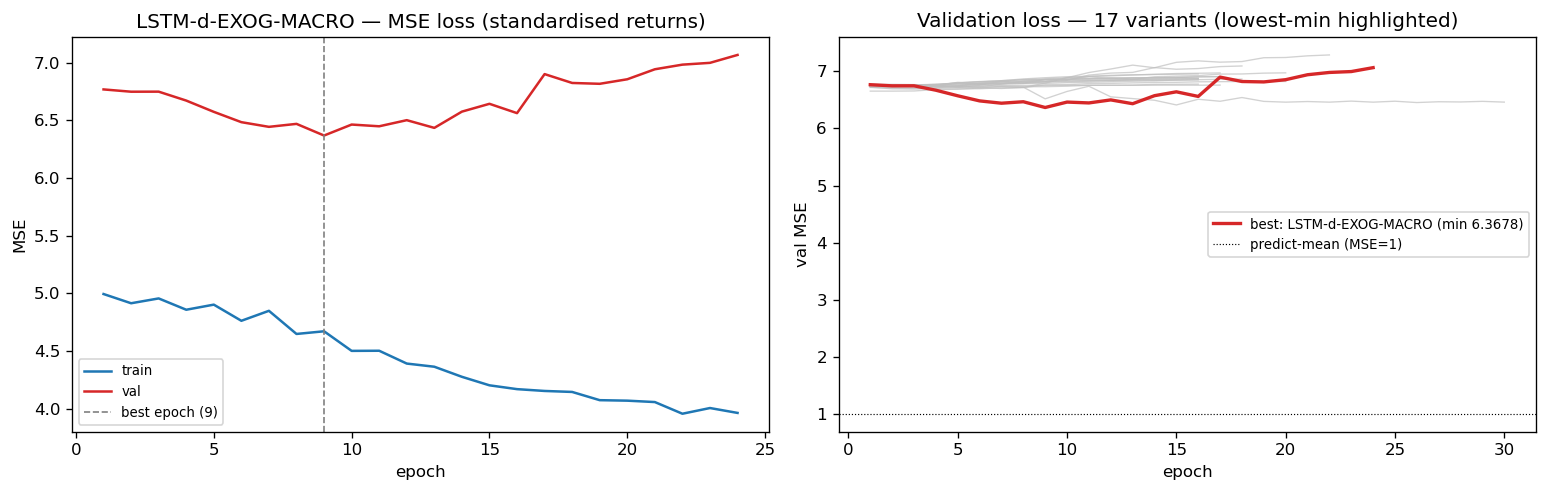

In [11]:
# Loss curves from the §5 training runs (LOSS_HISTORIES populated by run_variant).
assert LOSS_HISTORIES, 'Run §5 (Train variants) first to populate LOSS_HISTORIES.'

# Rank variants by the best (minimum) validation loss they reach -- this NAMES the
# variant whose curve looks like it "converges" lowest in the overlay.
rank = sorted(LOSS_HISTORIES, key=lambda n: min(LOSS_HISTORIES[n]['val']))
print(f'{"rank":>4}  {"variant":<30}  {"min val":>8}  {"@epoch":>6}  {"final val":>9}')
print('-' * 66)
for i, n in enumerate(rank, 1):
    v = LOSS_HISTORIES[n]['val']
    print(f'{i:>4}  {n:<30}  {min(v):>8.4f}  {int(np.argmin(v)) + 1:>6}  {v[-1]:>9.4f}')
best = rank[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# (a) the lowest-min-val variant: train vs val (does its 'convergence' hold up?)
h  = LOSS_HISTORIES[best]
ep = range(1, len(h['train']) + 1)
axes[0].plot(ep, h['train'], color='#1f77b4', label='train')
axes[0].plot(ep, h['val'],   color='#d62728', label='val')
axes[0].axvline(h['best_epoch'], color='grey', ls='--', lw=1, label=f"best epoch ({h['best_epoch']})")
axes[0].set(title=f'{best} — MSE loss (standardised returns)', xlabel='epoch', ylabel='MSE')
axes[0].legend(fontsize=8)

# (b) all variants' val loss; lowest-min highlighted, rest greyed (de-clutters the overlay)
for n in rank:
    if n == best:
        continue
    v = LOSS_HISTORIES[n]['val']
    axes[1].plot(range(1, len(v) + 1), v, color='0.75', lw=0.8, alpha=0.7, zorder=1)
vb = LOSS_HISTORIES[best]['val']
axes[1].plot(range(1, len(vb) + 1), vb, color='#d62728', lw=2.0, zorder=3,
             label=f'best: {best} (min {min(vb):.4f})')
axes[1].axhline(1.0, color='black', lw=0.7, ls=':', zorder=2, label='predict-mean (MSE=1)')
axes[1].set(title=f'Validation loss — {len(rank)} variants (lowest-min highlighted)',
            xlabel='epoch', ylabel='val MSE')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Results

**Metrics** — RMSE / MAE (magnitude), OOS R² (effect size vs Drift, shown as `r2_os` below), DA / WDA (direction). Formulas, caveats, and load-bearing status: `01_arima` §5 or [`notes.md`](../../notes.md).

Variant rows are **mean ± std over `SEEDS`** (benchmarks are single-run). The saved `metrics_lstm_daily_weekly.csv` carries the mean of each metric plus a `*_std` column; `all_preds` holds each variant's **median-RMSE seed** (the representative forecast used by §7–§10 and the cross-model leaderboard).

In [12]:
sys.path.insert(0, os.path.abspath('../../../../src'))
from eval_utils import oos_r2, period_metrics, diebold_mariano, PERIODS

# Naive baseline (single run, not seeded): predict y_t = y_{t-1}.
naive_pred = np.concatenate([[np.nan], actuals_arr[:-1]])
mask       = ~np.isnan(naive_pred)
n_acts     = actuals_arr[mask]
n_preds    = naive_pred[mask]
naive_row = {
    'model':   'Naive (t-1 week)',
    'rmse':    float(np.sqrt(mean_squared_error(n_acts, n_preds))),
    'mae':     float(mean_absolute_error(n_acts, n_preds)),
    'r2_os':   float('nan'),
    'dir_acc': float(np.mean(np.sign(n_acts) == np.sign(n_preds))),
    'wda':     float(np.sum(np.abs(n_acts) * (np.sign(n_acts) == np.sign(n_preds))) / np.sum(np.abs(n_acts))),
}

# Drift / random-walk-with-drift: prevailing (expanding) mean of weekly returns, aligned to
# LSTM test dates (strictly past returns -- no look-ahead). EMH floor; OOS R^2 = 0 by definition.
_ret       = weekly['silver_return'].dropna().sort_index()
drift_pred = np.array([_ret[_ret.index < d].mean() for d in pd.DatetimeIndex(dates_arr)])
drift_row  = {
    'model':   'Drift (prevailing mean)',
    'rmse':    float(np.sqrt(mean_squared_error(actuals_arr, drift_pred))),
    'mae':     float(mean_absolute_error(actuals_arr, drift_pred)),
    'r2_os':   0.0,
    'dir_acc': float(np.mean(np.sign(actuals_arr) == np.sign(drift_pred))),
    'wda':     float(np.sum(np.abs(actuals_arr) * (np.sign(actuals_arr) == np.sign(drift_pred))) / np.sum(np.abs(actuals_arr))),
}

# Per-seed metrics -> mean ± std for every variant. r2_os = % MSE reduction vs Drift (CT 2008).
# The representative forecast saved for §7 / the cross-model leaderboard is the median-RMSE seed
# (NOT the ensemble mean, which would understate error via variance reduction).
def _seed_metrics(pred):
    rmse = np.sqrt(mean_squared_error(actuals_arr, pred))
    mae  = mean_absolute_error(actuals_arr, pred)
    r2   = oos_r2(actuals_arr, pred, drift_pred) * 100
    da   = np.mean(np.sign(actuals_arr) == np.sign(pred))
    wda  = np.sum(np.abs(actuals_arr) * (np.sign(actuals_arr) == np.sign(pred))) / np.sum(np.abs(actuals_arr))
    return np.array([rmse, mae, r2, da, wda])

results      = {}    # name -> mean-metrics dict (consumed by §7 best-variant selection)
all_preds    = {}    # name -> representative (median-RMSE seed) forecast
seed_metrics = {}    # name -> (n_seeds, 5) per-seed [rmse, mae, r2_os, da, wda]
variant_rows = []
for name in variants:
    arr = SEED_PREDS[name]
    M   = np.vstack([_seed_metrics(p) for p in arr])
    seed_metrics[name] = M
    mean, std = M.mean(0), M.std(0)
    med = int(np.argsort(M[:, 0])[len(arr) // 2])     # median-RMSE seed = representative draw
    all_preds[name] = arr[med]
    results[name]   = {'model': name, 'rmse': mean[0], 'mae': mean[1],
                       'r2_os': mean[2], 'dir_acc': mean[3], 'wda': mean[4]}
    variant_rows.append({'model': name,
                         'rmse': mean[0], 'rmse_std': std[0],
                         'mae': mean[1],  'mae_std': std[1],
                         'r2_os': mean[2], 'r2_os_std': std[2],
                         'dir_acc': mean[3], 'dir_acc_std': std[3],
                         'wda': mean[4], 'wda_std': std[4]})

for r in (naive_row, drift_row):     # benchmarks carry no seed spread
    for k in ('rmse_std', 'mae_std', 'r2_os_std', 'dir_acc_std', 'wda_std'):
        r[k] = float('nan')

COLS = ['model', 'rmse', 'rmse_std', 'mae', 'mae_std', 'r2_os', 'r2_os_std',
        'dir_acc', 'dir_acc_std', 'wda', 'wda_std']
metrics_df = pd.DataFrame([naive_row, drift_row] + variant_rows)[COLS]
metrics_df.to_csv('../../../../data/processed/metrics_lstm_daily_weekly.csv', index=False)

print(f'Seeds: {SEEDS}   (variant rows = mean ± std over seeds; benchmarks single-run)')
print(f'{"Model":<30}  {"RMSE %":>14}  {"R2_OS %":>14}  {"DA":>6}  {"WDA":>14}')
print('-' * 92)
for _, row in metrics_df.iterrows():
    if pd.isna(row['rmse_std']):     # benchmark row
        r2 = 'n/a' if pd.isna(row['r2_os']) else f"{row['r2_os']:+.2f}"
        print(f"{row['model']:<30}  {row['rmse'] * 100:>6.2f}{'':>8}  {r2:>7}{'':>7}  "
              f"{row['dir_acc']:>6.3f}  {row['wda']:>6.3f}")
    else:
        print(f"{row['model']:<30}  {row['rmse'] * 100:>6.2f}±{row['rmse_std'] * 100:<5.2f}  "
              f"{row['r2_os']:>+6.2f}±{row['r2_os_std']:<5.2f}  {row['dir_acc']:>6.3f}  "
              f"{row['wda']:>6.3f}±{row['wda_std']:<5.2f}")

Seeds: [42, 0, 1, 2, 3]   (variant rows = mean ± std over seeds; benchmarks single-run)
Model                                   RMSE %         R2_OS %      DA             WDA
--------------------------------------------------------------------------------------------
Naive (t-1 week)                  7.59              n/a          0.491   0.490
Drift (prevailing mean)           5.19            +0.00          0.557   0.588
LSTM-d-Y                          5.17±0.02    +0.65±0.78    0.537   0.584±0.02 
LSTM-d-TECH                       5.23±0.02    -1.36±0.69    0.493   0.491±0.03 
LSTM-d-EXOG                       5.19±0.01    +0.17±0.23    0.561   0.609±0.02 
LSTM-d-EXOG-GS                    5.17±0.01    +0.93±0.36    0.534   0.549±0.02 
LSTM-d-EXOG-NONLIN                5.19±0.01    +0.19±0.46    0.552   0.584±0.01 
LSTM-d-EXOG-TECH                  5.27±0.07    -3.30±2.61    0.480   0.460±0.07 
LSTM-d-EXOG-MACRO                 5.18±0.02    +0.32±0.95    0.554   0.603±0.02 
LSTM-d-

## 7. Sub-period robustness + best-variant selection

In [13]:
def _period_r2_lstm(pred):
    drift_s = pd.Series(drift_pred, index=pd.DatetimeIndex(dates_arr))
    pred_s  = pd.Series(pred,       index=pd.DatetimeIndex(dates_arr))
    yt_s    = pd.Series(actuals_arr, index=pd.DatetimeIndex(dates_arr))
    r2 = {}
    for _lbl, (_a, _b) in PERIODS.items():
        _y, _p, _d = yt_s.loc[_a:_b].values, pred_s.loc[_a:_b].values, drift_s.loc[_a:_b].values
        if len(_y): r2[_lbl] = oos_r2(_y, _p, _d) * 100
    return r2

def _show_period_lstm(pred, csv=None):
    res = period_metrics(actuals_arr, pred, dates_arr, PERIODS)
    r2  = _period_r2_lstm(pred)
    res['R2_OS'] = [r2.get(lbl, float('nan')) for lbl in res.index]
    display(res[['n', 'RMSE', 'MAE', 'R2_OS', 'DA', 'WDA']].style
            .format({'n': '{:.0f}', 'RMSE': '{:.4f}', 'MAE': '{:.4f}',
                     'R2_OS': '{:+.2f}', 'DA': '{:.3f}', 'WDA': '{:.3f}'})
            .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.35, vmax=0.65))
    if csv:
        res[['n', 'DA', 'WDA']].to_csv(csv)   # legacy schema

def _save_preds_lstm(pred, csv):
    pd.DataFrame({'actual': actuals_arr, 'predicted': pred},
                 index=pd.DatetimeIndex(dates_arr)).rename_axis('Date').to_csv(csv)

best_name      = max(results, key=lambda k: results[k]['wda'])
best_name_rmse = min(results, key=lambda k: results[k]['rmse'])
best_pred      = all_preds[best_name]
best_pred_rmse = all_preds[best_name_rmse]
print(f'Best variant -- WDA: {best_name}  |  RMSE: {best_name_rmse}')

# Drift by period -- the floor (constant-sign, always-up; its DA/WDA = the up-share).
print('\nDrift (prevailing mean) by period -- the floor:')
_show_period_lstm(drift_pred)

print('\nWDA-best by period:')
_show_period_lstm(best_pred, '../../../../data/processed/period_lstm_daily_weekly.csv')
print('RMSE-best by period:')
_show_period_lstm(best_pred_rmse, '../../../../data/processed/period_lstm_daily_rmse_weekly.csv')

_save_preds_lstm(best_pred,      '../../../../data/processed/preds_lstm_daily_best_weekly.csv')
_save_preds_lstm(best_pred_rmse, '../../../../data/processed/preds_lstm_daily_bestrmse_weekly.csv')
print('\nSaved: period + preds (WDA-best legacy names, RMSE-best alongside).')

# Drift WDA by period (the directional benchmark to beat).
_yt = pd.Series(actuals_arr, index=pd.DatetimeIndex(dates_arr))
print('\nDrift WDA by period (directional benchmark to beat):')
for _lbl, (_a, _b) in PERIODS.items():
    _s = _yt.loc[_a:_b]
    if len(_s):
        _au = np.sum(np.abs(_s.values) * (_s.values > 0)) / np.sum(np.abs(_s.values))
        print(f'  {_lbl:20s} WDA={_au:.3f}  (n={len(_s)})')


Best variant -- WDA: LSTM-d-EXOG-COT  |  RMSE: LSTM-d-EXOG-GS

Drift (prevailing mean) by period -- the floor:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0400,0.0318,+0.00,0.481,0.492
2024 (bull start),52,0.0380,0.0299,+0.00,0.500,0.570
2025 (bull run),52,0.0498,0.0352,+0.00,0.692,0.757
2026 (YTD),18,0.1003,0.0791,+0.00,0.556,0.498
── Full test ──,174,0.0519,0.0371,+0.00,0.557,0.588



WDA-best by period:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0399,0.0317,+0.64,0.500,0.493
2024 (bull start),52,0.0379,0.0299,+0.54,0.577,0.666
2025 (bull run),52,0.0500,0.0356,-0.49,0.615,0.719
2026 (YTD),18,0.0997,0.0789,+1.31,0.556,0.627
── Full test ──,174,0.0518,0.0372,+0.57,0.563,0.629


RMSE-best by period:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0396,0.0313,+1.95,0.462,0.424
2024 (bull start),52,0.0379,0.0303,+0.64,0.500,0.561
2025 (bull run),52,0.0497,0.0350,+0.45,0.577,0.551
2026 (YTD),18,0.1001,0.0800,+0.58,0.389,0.488
── Full test ──,174,0.0517,0.0372,+0.80,0.500,0.507



Saved: period + preds (WDA-best legacy names, RMSE-best alongside).

Drift WDA by period (directional benchmark to beat):
  2023  (choppy)       WDA=0.492  (n=52)
  2024  (bull start)   WDA=0.570  (n=52)
  2025  (bull run)     WDA=0.757  (n=52)
  2026  (YTD)          WDA=0.498  (n=18)
  ── Full test ──      WDA=0.588  (n=174)


## 8. Predicted vs actual — best variants

Two panels: WDA-best (directional pick) and RMSE-best (magnitude pick), each plotted against
the actual return and the Drift floor. Drift is constant-positive — its curve shows where an
always-up call would sit.

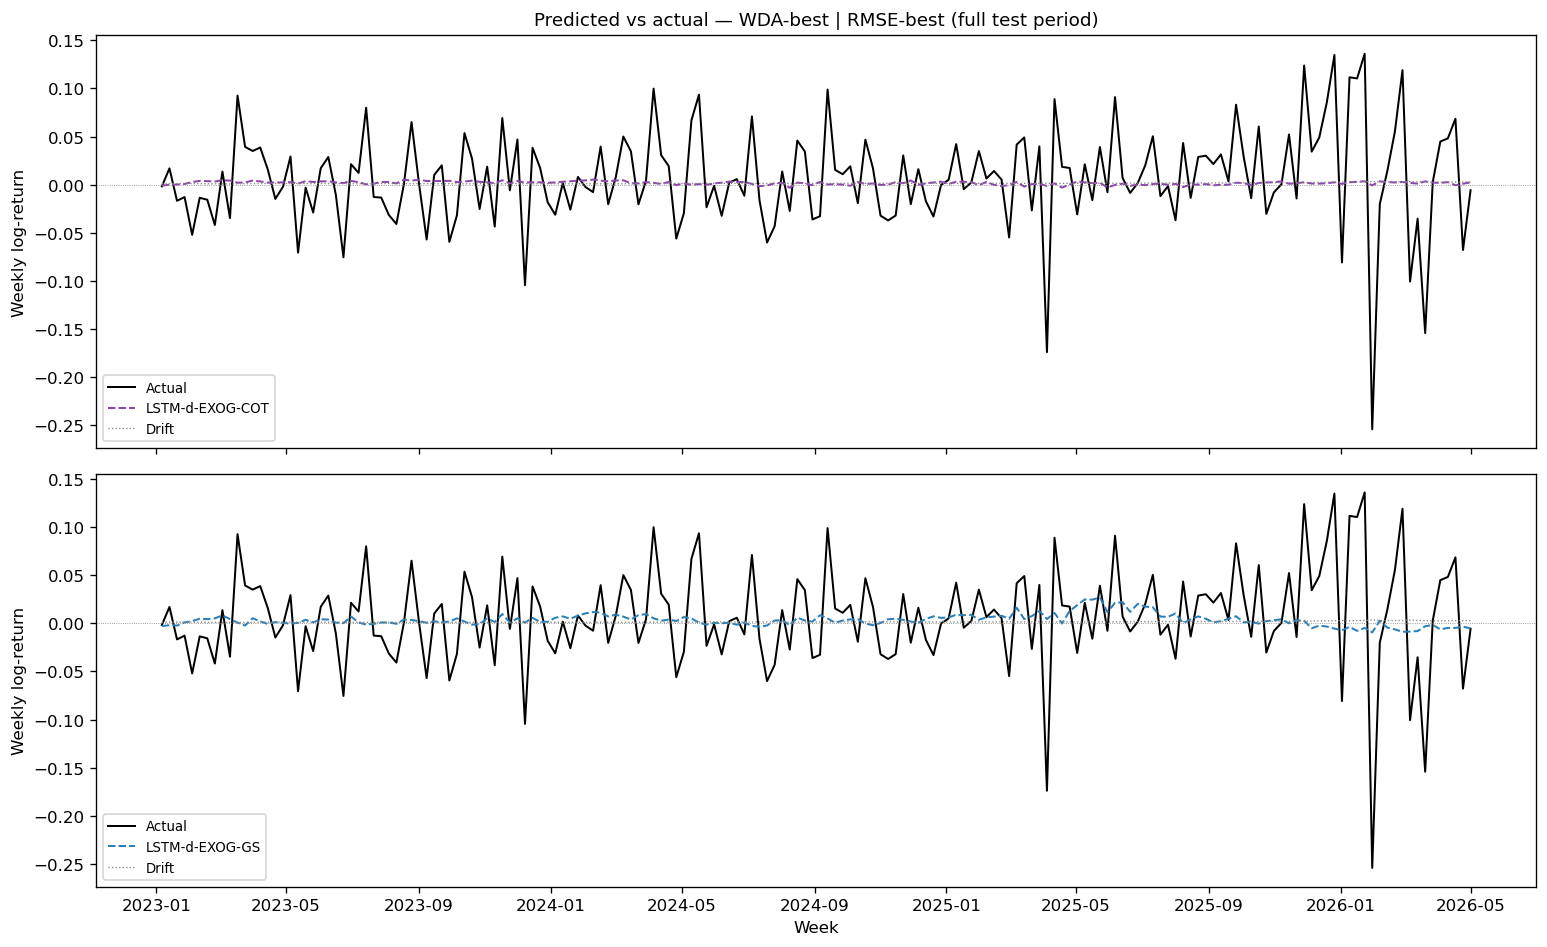

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

_idx   = pd.DatetimeIndex(dates_arr)
_act   = pd.Series(actuals_arr,  index=_idx)
_drift = pd.Series(drift_pred,   index=_idx)
_wda   = pd.Series(best_pred,    index=_idx)
_rmse  = pd.Series(best_pred_rmse, index=_idx)

for ax, pred_s, label, color in [
    (axes[0], _wda,  best_name,      '#8e44ad'),
    (axes[1], _rmse, best_name_rmse, '#2980b9'),
]:
    ax.plot(_idx, _act,   color='black',  lw=1.2, label='Actual')
    ax.plot(_idx, pred_s, color=color,    lw=1.2, ls='--', label=label)
    ax.plot(_idx, _drift, color='#888',   lw=0.8, ls=':',  label='Drift')
    ax.axhline(0, color='grey', lw=0.5, ls=':')
    ax.set_ylabel('Weekly log-return')
    ax.legend(fontsize=8)

axes[0].set_title('Predicted vs actual — WDA-best | RMSE-best (full test period)', fontsize=11)
axes[1].set_xlabel('Week')
plt.tight_layout()
plt.show()


## 9. Significance tests

### DM — squared-error floor (load-bearing)

The headline test: does any variant produce significantly lower **squared** forecast errors than
the Drift? This is the proper significance test for the OOS R² in §6 (both MSFE-based).

The first table runs DM on each variant's **representative (median-seed)** forecast; the second
reports the **per-seed** DM spread — `mean DM`, range, and how many of the seeds actually clear
the floor (`p<0.05`). A variant that beats drift in only a few seeds is a lucky draw, not skill.

In [15]:
# Semi-strong floor [PRIMARY] — squared-error loss vs Drift.
# DM is the significance test for the OOS R^2 in §6 (both MSFE-based). all_preds holds each
# variant's representative (median-RMSE) seed; the per-seed spread is summarised below it.
print("Diebold-Mariano -- vs Drift floor   [squared error]   (representative median-seed forecast)")
print("Semi-strong test: can any variant beat the no-predictability drift?")
print("-" * 92)
for name, pred in all_preds.items():
    diebold_mariano(actuals_arr, drift_pred, pred, "Drift", name)

# Seed-robustness of the floor test: across the seeds, how often does a variant's forecast
# actually clear the DM floor? A result significant in only a handful of seeds is a lucky draw,
# not skill -- this is the load-bearing defence against a "lucky seed" critique.
import io, contextlib
def _dm_se(pred):
    with contextlib.redirect_stdout(io.StringIO()):
        return diebold_mariano(actuals_arr, drift_pred, pred, "Drift", "_", loss='se')

print("\nSeed-robustness — per-seed DM vs Drift (squared error):")
print(f'{"variant":<30}  {"mean DM":>8}  {"min":>7}  {"max":>7}  {"seeds beating Drift p<.05":>26}')
print("-" * 92)
for name in variants:
    ds = [d for d in (_dm_se(p) for p in SEED_PREDS[name]) if d is not None]
    dm = [d['dm'] for d in ds]
    nsig = sum(1 for d in ds if d['dm'] > 0 and d['p'] < 0.05)
    print(f'{name:<30}  {np.mean(dm):>+8.3f}  {min(dm):>+7.2f}  {max(dm):>+7.2f}  {f"{nsig}/{len(ds)}":>26}')

Diebold-Mariano -- vs Drift floor   [squared error]   (representative median-seed forecast)
Semi-strong test: can any variant beat the no-predictability drift?
--------------------------------------------------------------------------------------------
Drift                                    vs LSTM-d-Y                                  DM=+1.173  p=0.241  (ns)  -> winner: tie
Drift                                    vs LSTM-d-TECH                               DM=-0.952  p=0.341  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG                               DM=+0.076  p=0.939  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG-GS                            DM=+0.407  p=0.684  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG-NONLIN                        DM=+0.366  p=0.715  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG-TECH                          DM=-0.838  p=0.402  (ns)  

### DM — absolute-error (robustness)

Same framework, loss $\lvert y-\hat y\rvert$ instead of $(y-\hat y)^2$. Weekly silver returns
are heavy-tailed — a few outlier weeks dominate squared loss. Absolute-error checks whether
the result survives a less outlier-sensitive criterion. Squared error stays the headline.

In [16]:
# Robustness -- floor test under ABSOLUTE-error loss.
print("Diebold-Mariano -- vs Drift floor   [absolute-error loss, robustness]")
print("-" * 90)
for name, pred in all_preds.items():
    diebold_mariano(actuals_arr, drift_pred, pred, "Drift", name, loss='ae')

Diebold-Mariano -- vs Drift floor   [absolute-error loss, robustness]
------------------------------------------------------------------------------------------
Drift                                    vs LSTM-d-Y                                  DM=+0.276  p=0.782  (ns)  -> winner: tie
Drift                                    vs LSTM-d-TECH                               DM=-1.340  p=0.180  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG                               DM=+0.011  p=0.991  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG-GS                            DM=-0.077  p=0.938  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG-NONLIN                        DM=-0.219  p=0.827  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG-TECH                          DM=-1.098  p=0.272  (ns)  -> winner: tie
Drift                                    vs LSTM-d-EXOG-MACRO                

## 9b. Directional test — Pesaran–Timmermann (secondary lens)

In [17]:
from eval_utils import pesaran_timmermann

print("Pesaran-Timmermann directional test — full test window")
print("H0: predicted & actual signs independent  |  * p<0.05  ** p<0.01  *** p<0.001")
print("-" * 90)
pesaran_timmermann(actuals_arr, drift_pred, name="Drift (always-up)")   # degenerate ref
pt_results = {n: pesaran_timmermann(actuals_arr, p, name=n) for n, p in all_preds.items()}
_tested = [r for r in pt_results.values() if not np.isnan(r['p'])]
_sig    = {n: r for n, r in pt_results.items() if not np.isnan(r['p']) and r['p'] < 0.05}
print(f"\n{len(_sig)}/{len(_tested)} variants significant at p<0.05 "
      f"(~{0.05 * len(_tested):.1f} expected by chance): {list(_sig)}")

print(f"\nPer-period PT — {best_name}:")
_yt = pd.Series(actuals_arr, index=pd.DatetimeIndex(dates_arr))
_bp = pd.Series(best_pred, index=pd.DatetimeIndex(dates_arr))
for _lbl, (_a, _b) in PERIODS.items():
    _yy = _yt.loc[_a:_b].values
    _pp = _bp.loc[_a:_b].values
    if len(_yy) >= 12:
        pesaran_timmermann(_yy, _pp, name=f"  {_lbl}  (n={len(_yy)})")

Pesaran-Timmermann directional test — full test window
H0: predicted & actual signs independent  |  * p<0.05  ** p<0.01  *** p<0.001
------------------------------------------------------------------------------------------
Drift (always-up)                         DA=0.557  DA|indep=0.557  PT degenerate (constant-sign forecast)  -> winner: n/a
LSTM-d-Y                                  DA=0.557  DA|indep=0.557  PT degenerate (constant-sign forecast)  -> winner: n/a
LSTM-d-TECH                               DA=0.466  DA|indep=0.458  PT=+0.276  p=0.783  (ns)  -> winner: tie (chance)
LSTM-d-EXOG                               DA=0.563  DA|indep=0.554  PT=+0.721  p=0.471  (ns)  -> winner: tie (chance)
LSTM-d-EXOG-GS                            DA=0.500  DA|indep=0.530  PT=-0.925  p=0.355  (ns)  -> winner: tie (chance)
LSTM-d-EXOG-NONLIN                        DA=0.546  DA|indep=0.551  PT=-0.280  p=0.780  (ns)  -> winner: tie (chance)
LSTM-d-EXOG-TECH                          DA=0.523  DA|ind

## 9c. Robustness — drop the 2025 bull run (full battery)

2025 carries the entire always-up directional line, so once the full-window tests are done,
re-run **the whole battery** — metrics + OOS R² + DM floor (se/ae) + PT — on **2023 + 2024 + 2026**
only. Evaluation-only (models unchanged); pooled (per-year DM is underpowered). The efficiency
conclusion *strengthens* once the bull is removed.

In [18]:
from eval_utils import pesaran_timmermann
# Full battery on the non-bull window — evaluation only, forecasts unchanged.
mask_ex25 = np.array(pd.DatetimeIndex(dates_arr).year != 2025)
a_ex      = actuals_arr[mask_ex25]
drift_ex  = drift_pred[mask_ex25]
dates_ex  = pd.DatetimeIndex(dates_arr)[mask_ex25]
_preds_ex = {name: np.asarray(pred)[mask_ex25] for name, pred in all_preds.items()}
au_ex     = np.sum(np.abs(a_ex) * (a_ex > 0)) / np.sum(np.abs(a_ex))
print(f'Ex-2025 sample: {int(mask_ex25.sum())} weeks  |  always-up WDA = {au_ex:.3f}')

print('\nMetrics (2025 excluded) -- RMSE / MAE / DA / WDA:')
from sklearn.metrics import mean_squared_error, mean_absolute_error
for name, pred_ex in _preds_ex.items():
    rmse = np.sqrt(mean_squared_error(a_ex, pred_ex))
    mae  = mean_absolute_error(a_ex, pred_ex)
    da   = np.mean(np.sign(a_ex) == np.sign(pred_ex))
    wda  = np.sum(np.abs(a_ex) * (np.sign(a_ex) == np.sign(pred_ex))) / np.sum(np.abs(a_ex))
    print(f'{name:<35}  RMSE={rmse:.5f}  MAE={mae:.5f}  DA={da:.3f}  WDA={wda:.3f}')

print('\nOOS R^2 vs Drift (2025 excluded):')
print('-' * 90)
for name, pred_ex in _preds_ex.items():
    _r2 = oos_r2(a_ex, pred_ex, drift_ex) * 100
    print(f'  {name:35s} R2_OS = {_r2:+6.2f}%   -> winner: {name if _r2 > 0 else "Drift"}')

print('\nDM -- vs Drift floor, 2025 excluded [squared error]:')
print('-' * 90)
for name, pred_ex in _preds_ex.items():
    diebold_mariano(a_ex, drift_ex, pred_ex, 'Drift', name)

print('\nDM -- vs Drift floor, 2025 excluded [absolute-error loss, robustness]:')
print('-' * 90)
for name, pred_ex in _preds_ex.items():
    diebold_mariano(a_ex, drift_ex, pred_ex, 'Drift', name, loss='ae')

print('\nPesaran-Timmermann (2025 excluded):')
print('-' * 90)
for name, pred_ex in _preds_ex.items():
    pesaran_timmermann(a_ex, pred_ex, name=name)


Ex-2025 sample: 122 weeks  |  always-up WDA = 0.520

Metrics (2025 excluded) -- RMSE / MAE / DA / WDA:
LSTM-d-Y                             RMSE=0.05263  MAE=0.03795  DA=0.500  WDA=0.520
LSTM-d-TECH                          RMSE=0.05259  MAE=0.03789  DA=0.533  WDA=0.529
LSTM-d-EXOG                          RMSE=0.05265  MAE=0.03785  DA=0.525  WDA=0.537
LSTM-d-EXOG-GS                       RMSE=0.05251  MAE=0.03806  DA=0.467  WDA=0.490
LSTM-d-EXOG-NONLIN                   RMSE=0.05268  MAE=0.03807  DA=0.492  WDA=0.541
LSTM-d-EXOG-TECH                     RMSE=0.05228  MAE=0.03761  DA=0.598  WDA=0.631
LSTM-d-EXOG-MACRO                    RMSE=0.05384  MAE=0.03933  DA=0.500  WDA=0.520
LSTM-d-EXOG-FRED                     RMSE=0.05277  MAE=0.03804  DA=0.484  WDA=0.458
LSTM-d-EXOG-COT                      RMSE=0.05250  MAE=0.03786  DA=0.541  WDA=0.592
LSTM-d-EXOG-FRED-COT                 RMSE=0.05271  MAE=0.03803  DA=0.492  WDA=0.485
LSTM-d-EXOG-REDDIT                   RMSE=0.05266  MAE=0.

## 10. 2026 zoom — actual vs best variants

Most recent out-of-sample slice, where silver has been most active. Two panels: WDA-best
(directional pick) and RMSE-best (magnitude pick), each with the Drift floor overlaid.

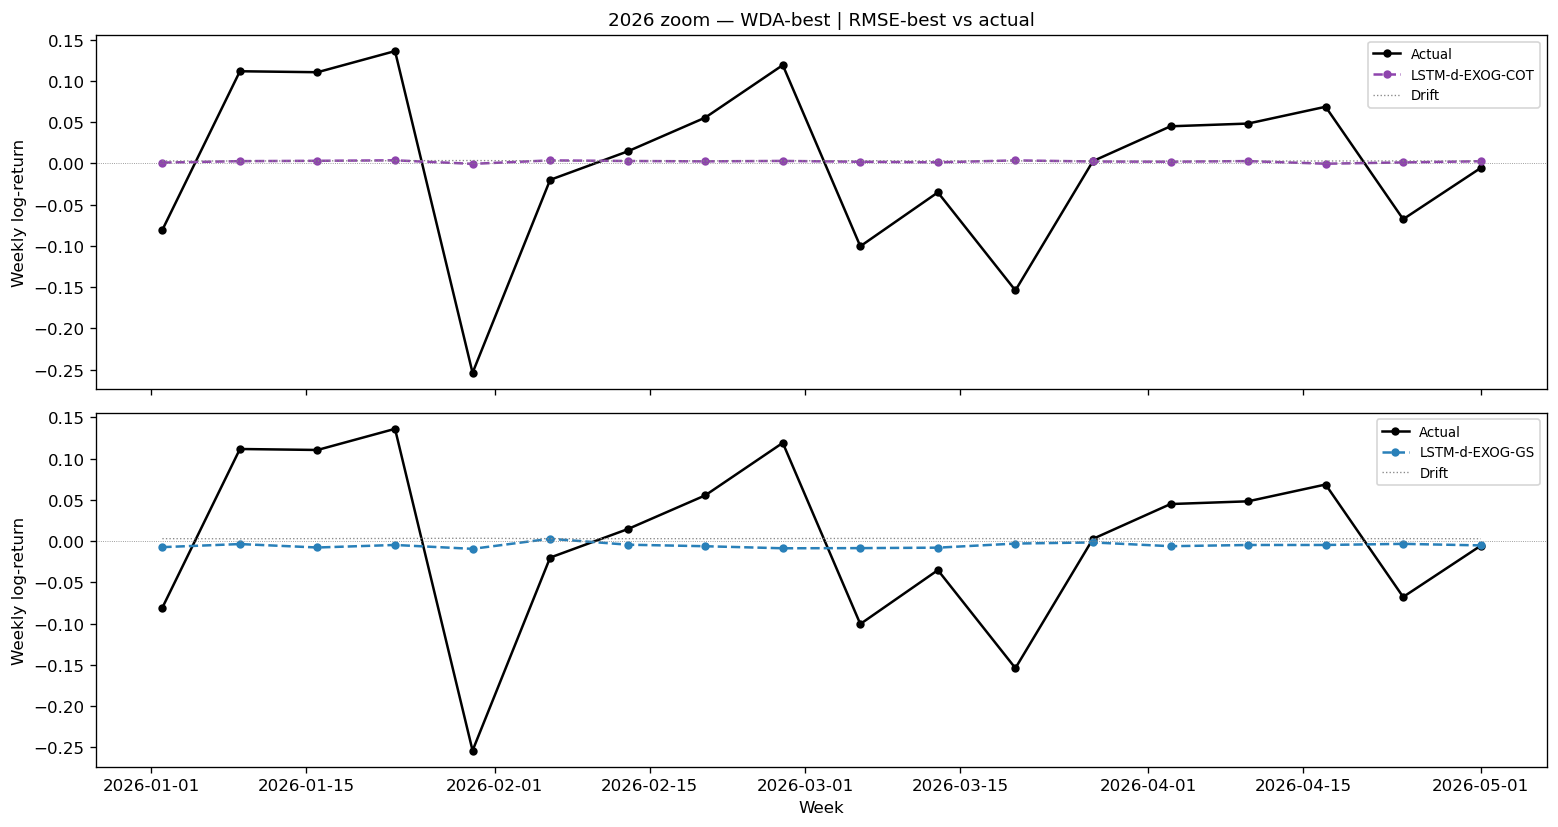

In [19]:
_idx26  = pd.DatetimeIndex(dates_arr)
_mask26 = _idx26.year == 2026

if _mask26.sum() == 0:
    print('No 2026 data in test set yet.')
else:
    _act26   = actuals_arr[_mask26]
    _drift26 = drift_pred[_mask26]
    _wda26   = best_pred[_mask26]
    _rmse26  = best_pred_rmse[_mask26]
    _dates26 = _idx26[_mask26]

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    for ax, pred26, label, color in [
        (axes[0], _wda26,  best_name,      '#8e44ad'),
        (axes[1], _rmse26, best_name_rmse, '#2980b9'),
    ]:
        ax.plot(_dates26, _act26,   color='black', lw=1.5, marker='o', ms=4, label='Actual')
        ax.plot(_dates26, pred26,   color=color,   lw=1.5, marker='o', ms=4, ls='--', label=label)
        ax.plot(_dates26, _drift26, color='#888',  lw=0.8, ls=':',               label='Drift')
        ax.axhline(0, color='grey', lw=0.5, ls=':')
        ax.set_ylabel('Weekly log-return')
        ax.legend(fontsize=8)

    axes[0].set_title('2026 zoom — WDA-best | RMSE-best vs actual', fontsize=11)
    axes[1].set_xlabel('Week')
    plt.tight_layout()
    plt.show()
